In [22]:
import math
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from graphcast.model_utils import stacked_to_dataset
from graphcast.losses import normalized_latitude_weights
from graphufs.stacked_utils import get_channel_index
from graphufs.datasets import Dataset
from prototypes.ocn_only.emulator import OcnEvaluator, OcnTrainer

In [2]:
def climatology(model_type:str, prototype:str):

    #### SETUP ####
    ocn_only_home = f"/global/homes/n/nagarwal/graph-ufs/prototypes/{model_type}"
    config_trainer_path = f"{ocn_only_home}/{prototype}/config.yaml"
    emulator = OcnTrainer(config=config_trainer_path)
    preserved_dims = ("lat", "lon")

    #### LOAD AND PREPARE THE STACKED DATA ####
    # read in the training data
    train_dir = f"{emulator.local_store_path}/training"
    training_targets = xr.open_zarr(f"{train_dir}/targets.zarr")["targets"] # (sample, lat, lon, channels)

    # climatology
    climatology = training_targets.mean(dim="sample") # (lat, lon, channels)

    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)

    #### UNSTACK CLIMATOLOGY ####
    clima_unstacked = stacked_to_dataset(climatology.variable, 
                                         xtargets.isel(batch=0, time=0, drop=True), 
                                         preserved_dims=preserved_dims)
    return clima_unstacked

In [3]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates, 
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

In [4]:
def calculate_the_metric(model_pred, ref_truth, metric="SQE", clima=None):
    """
    Calculates the given metric against the reference truth.
    The metric parameter can take the following values: "SQE"/"ABS"/"ACC"
    """
    # Create a land/sea mask based on the salinity field at the first time step
    mask = xr.where(ref_truth.so.isel(time=0, lead_time=0) == 0, 0, 1)
    
    error_metric_vars = {}
    
    # Pre-calculate reference anomaly
    if metric.lower() == "acc": 
        reference_anomaly_all = ref_truth - clima

    for var in model_pred.data_vars:
        # Determine the correct mask to use for this variable (with or without depth)
        current_mask = mask if "z_l" in model_pred[var].dims else mask.isel(z_l=0)
        
        # Compute error and apply mask
        error = (model_pred[var] - ref_truth[var]) * current_mask

        # ---- calculate the appropriate metric using the above error statistics ----
        # SQE (squared error)
        if metric.lower() == "sqe":
            error_metric_vars[var] = error**2
        
        # ABS (absolute error)
        elif metric.lower() == "abs":
            error_metric_vars[var] = abs(error)
        
        else:
            raise KeyError(f"{metric} is not recognized. Only SQE and ABS are supported")
        
    return error_metric_vars

## Config and Computation 

In [5]:
# ---- Config ----
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"
PLOT_METRIC = "RMSE"

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-Maha",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
]

In [6]:
# ---- The Main Computation Block ----
# Initialize dictionaries to store all results
all_error = {}
    
# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")
        
    all_error[model_name] = {}
    
    # Load the model prediction data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
        
    # Loop over the truth references for this model
    for truth_name in TRUTHS:
        print(f"Comparing against truth: {truth_name} ...")
            
        # Construct the path to the truth data
        if model_config["type"] in ["persistence", "climatology"]:
            # Logic to find the corresponding replay file for baselines
            run = "R5" if model_config['timestep'] == "24h" else "R4"
            expt = "T1M" if model_config['timestep'] == "24h" else "T3M"
            duration = "240h"
            location = os.path.join(SCRATCH_DIR, model_config["model_type"], run, f"inference_{expt}/validation/")
            fname = f"{location}/replay.{duration}.zarr"
        else:
            infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
            location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
            fname = f"{location}/{truth_name.lower()}.{model_config['duration']}.zarr"

        ref_truth = xr.open_zarr(fname)
            
        # Calculate the desired metric for this model against this truth
        if PLOT_METRIC.lower() == "rmse":
            metric = "SQE"
        elif PLOT_METRIC.lower() == "mae":
            metric = "ABS"
        else:
            raise KeyError(f"The desired metric is not recognized. Only RMSE and MAE are supported")

        # Compute the error metric
        error = calculate_the_metric(model_pred, ref_truth, metric=metric)
            
        # Store results
        all_error[model_name][truth_name] = error

print("\n--- Metric calculation complete!! ---")


Processing Model: Emulator-24h-MSE
Comparing against truth: Replay ...

Processing Model: Emulator-24h-Maha
Comparing against truth: Replay ...

--- Metric calculation complete!! ---


## Plotting 

In [7]:
def calculate_rmse(sqerr_da, apply_weighting=False, depth_level=0, 
                   dims_to_skip_for_avg=["lead_time", "time"]):
    """
    Calculates the Root Mean Squared Error from a squared error DataArray.
    
    This function correctly preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in sqerr_da.dims:
        sqerr_da = sqerr_da.isel(z_l=depth_level)
    
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(sqerr_da)
        sqerr_da = sqerr_da * weights.astype(sqerr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    # The 'time' dimension (or 'init_time') holds the samples for the CI.
    dims_to_avg = [dim for dim in sqerr_da.dims if dim not in dims_to_skip_for_avg]
    
    # Calculate the mean over spatial dimensions and take the square root
    rmse_da = np.sqrt(sqerr_da.mean(dim=dims_to_avg))
    
    return rmse_da

In [8]:
def calculate_mae(abserr_da, apply_weighting=False, depth_level=0, 
                  dims_to_skip_for_avg=["lead_time", "time"]):
    """
    Calculates the Mean Absolute Error from an absolute error DataArray.
    
    This function preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in abserr_da.dims:
        abserr_da = abserr_da.isel(z_l=depth_level)
    
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(abserr_da)
        abserr_da = abserr_da * weights.astype(abserr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    dims_to_avg = [dim for dim in abserr_da.dims if dim not in dims_to_skip_for_avg]
    
    # Calculate the mean over spatial dimensions
    mae_da = abserr_da.mean(dim=dims_to_avg)
    
    return mae_da

In [52]:
def plot_spatial_error(ax,
                       da_2d: xr.DataArray,
                       cmap: str = 'cividis', # A great default for sequential data
                       vmin: float = None,
                       vmax: float = None,
                       add_colorbar: bool = False, # Crucial: colorbars will be added manually
                      ):
    """
    Plots a 2D spatial error map with manuscript-quality features.
    The input DataArray must be 2D (lat, lon).
    """
    # Plot the data
    p = da_2d.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=add_colorbar,  
        add_labels=False,
    )

    # Add geographical features for context
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k', facecolor='lightgray')
    ax.coastlines(resolution='50m', color='black', linewidth=0.7)
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    return p

In [30]:
# ---- Units ----
units = {}
units["SSH"] = "m"
units["so"] = "psu"
units["temp"] = "degC"
units["uo"] = "m/s"
units["vo"] = "m/s"

In [31]:
# ---- Error Bounds ----
error_bounds = {}

# RMSE
error_bounds["RMSE"] = {}
error_bounds["RMSE"]["SSH"] = {"vmin":0, "vmax":0.05}  # 0-15 cm
error_bounds["RMSE"]["so"] = {"vmin":0, "vmax":0.2}   # 0-0.4 psu
error_bounds["RMSE"]["temp"] = {"vmin":0, "vmax":0.5} # 0-0.5 degC
error_bounds["RMSE"]["uo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
error_bounds["RMSE"]["vo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
###################
# MAE
error_bounds["MAE"] = {}
error_bounds["MAE"]["SSH"] = {"vmin":0, "vmax":0.025}  # 0-16 cm
error_bounds["MAE"]["so"] = {"vmin":0, "vmax":0.07}   # 0-0.4 psu
error_bounds["MAE"]["temp"] = {"vmin":0, "vmax":0.25} # 0-0.5 degC
error_bounds["MAE"]["uo"] = {"vmin":0, "vmax":0.07}  # 0-0.25 m/s
error_bounds["MAE"]["vo"] = {"vmin":0, "vmax":0.07}  # 0-0.25 m/s
###################
# ACC
error_bounds["ACC"] = {}
error_bounds["ACC"]["SSH"] = {"vmin":0.7, "vmax":1}  # 0-16 cm
error_bounds["ACC"]["so"] = {"vmin":0.85, "vmax":1}   # 0-0.4 psu
error_bounds["ACC"]["temp"] = {"vmin":0.9, "vmax":1} # 0-0.5 degC
error_bounds["ACC"]["uo"] = {"vmin":0.4, "vmax":1}  # 0-0.25 m/s
error_bounds["ACC"]["vo"] = {"vmin":0.2, "vmax":1}  # 0-0.25 m/s

In [32]:
# ---- Plotting Settings ----
var_list = ["temp", "so"] 
print_name = ["SST", "SSS"]
iz_l = 0

SAVE_PLOT = False # remember to change the file name if needed
APPLY_LATITUDE_WEIGHTING = False
PLOT_FORECAST_DAY = 10

--- Processing Truth: Replay ---
model: Emulator-24h-MSE
model: Emulator-24h-Maha


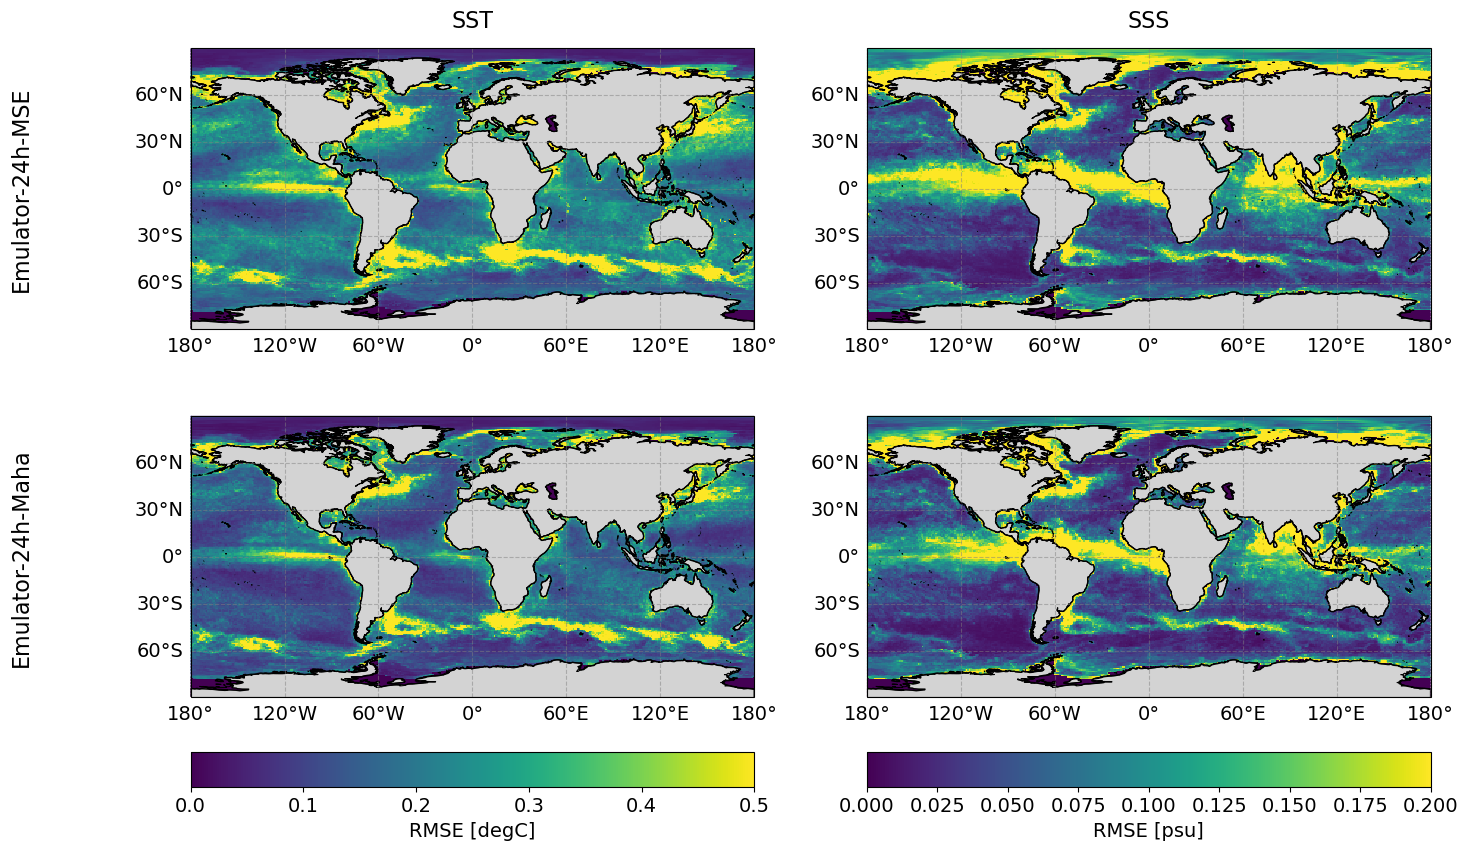

In [45]:
# ---- Global Settings ----
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': 'DejaVu Sans', 'font.size': 14})

for truth in TRUTHS:
    print(f"--- Processing Truth: {truth} ---")

    # --- 1. Setup the Figure and GridSpec Layout ---
    # Rows are models, columns are variables
    nrows = len(MODELS_CONFIG)
    ncols = len(var_list)
    
    # Create a grid: one row per model, one column per variable + a thin row for colorbars at the bottom
    fig = plt.figure(figsize=(8 * ncols, 5 * nrows))
    gs = gridspec.GridSpec(nrows + 1, ncols, figure=fig, 
                           height_ratios=[1] * nrows + [0.1], 
                           wspace=0.2, hspace=0.1)

    # --- 2. Main Plotting Loop ---
    mappables = {} # To store plot objects for colorbars

    for i, config in enumerate(MODELS_CONFIG): # Loop over rows (models)
        model_name = config["name"]
        print(f"model: {model_name}")
        
        for j, var_name in enumerate(var_list): # Loop over columns (variables)
            ax = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
            
            # --- Data Preparation ---
            # This logic should be adapted to your new 'all_error' structure
            err = all_error[model_name][truth][var_name] # Assuming squared error
            
            # Calculate the metric (e.g., RMSE)
            if PLOT_METRIC == "RMSE":
                metric_to_plot = calculate_rmse(err, 
                                                apply_weighting=APPLY_LATITUDE_WEIGHTING, 
                                                depth_level=iz_l,
                                                dims_to_skip_for_avg=["lat","lon","lead_time"],
                                               )
            elif PLOT_METRIC == "MAE":
                metric_to_plot = calculate_mae(err, 
                                               apply_weighting=APPLY_LATITUDE_WEIGHTING, 
                                               depth_level=iz_l,
                                               dims_to_skip_for_avg=["lat","lon","lead_time"],
                                              )
            
            # Select the forecast day to plot
            timestep_hours = int(config["timestep"][:-1])
            steps_per_day = 24 // timestep_hours
            forecast_day_idx = PLOT_FORECAST_DAY * steps_per_day
            data_for_day = metric_to_plot.isel(lead_time=forecast_day_idx - 1)
            
            # --- Plotting ---
            p = plot_spatial_error(
                ax, data_for_day,
                vmin=error_bounds["RMSE"][var_name]["vmin"],
                vmax=error_bounds["RMSE"][var_name]["vmax"],
                cmap='viridis' # Another excellent choice
            )
            
            # Store the mappable from the first row to create the colorbar later
            if i == 0:
                mappables[j] = p

            # --- Set Titles and Labels ---
            # Add variable names as column titles on the top row
            if i == 0:
                ax.set_title(print_name[j], fontsize=16, pad=15)
            # Add model names as row titles on the first column
            if j == 0:
                ax.text(-0.3, 0.5, model_name, transform=ax.transAxes, 
                        ha='center', va='center', rotation='vertical', fontsize=16)

    # --- 3. Add Shared Colorbars ---
    # Create a shared colorbar for each variable column at the bottom
    for j, var_name in enumerate(var_list):
        cax = fig.add_subplot(gs[nrows, j])
        cbar = fig.colorbar(mappables[j], cax=cax, orientation='horizontal')
        cbar.set_label(f"RMSE [{units.get(var_name, '')}]")
    
    # Save the figure
    if SAVE_PLOT:
        figname = f"Spatial_RMSE_Day{PLOT_FORECAST_DAY}_{truth}.png"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()

--- Processing Truth: Replay ---
model: Emulator-24h-MSE
model: Emulator-24h-Maha


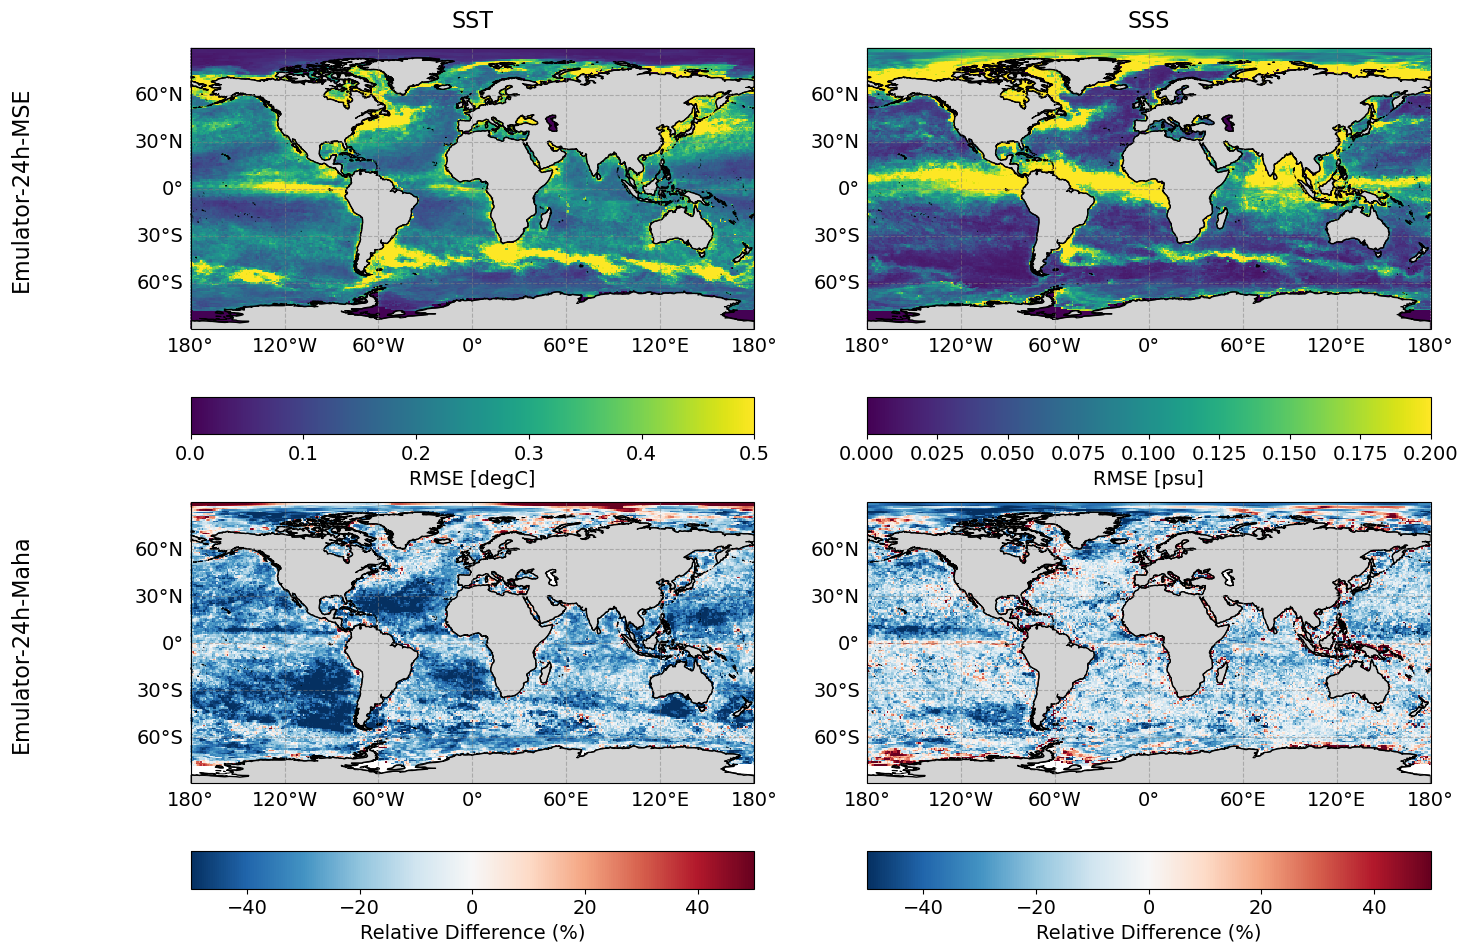

In [66]:
# ---- Global Settings ----
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': 'DejaVu Sans', 'font.size': 14})

for truth in TRUTHS:
    print(f"--- Processing Truth: {truth} ---")

    # --- Pre-calculate Baseline Error for the first model ---
    baseline_error_maps = {}
    baseline_config = MODELS_CONFIG[0]
    model_name_baseline = baseline_config["name"]

    for var_name in var_list:
        err = all_error[model_name_baseline][truth][var_name]
        
        if PLOT_METRIC == "RMSE":
            metric_map = calculate_rmse(err, APPLY_LATITUDE_WEIGHTING, iz_l, ["lat","lon","lead_time"])
        elif PLOT_METRIC == "MAE":
            metric_map = calculate_mae(err, APPLY_LATITUDE_WEIGHTING, iz_l, ["lat","lon","lead_time"])
            
        timestep_hours = int(baseline_config["timestep"][:-1])
        steps_per_day = 24 // timestep_hours
        forecast_day_idx = PLOT_FORECAST_DAY * steps_per_day
        baseline_error_maps[var_name] = metric_map.isel(lead_time=forecast_day_idx - 1)

    # --- Setup the Figure and GridSpec Layout ---
    nrows = len(MODELS_CONFIG)
    ncols = len(var_list)
    
    fig = plt.figure(figsize=(8 * ncols, 6 * nrows))
    gs = gridspec.GridSpec(nrows + 2, ncols, figure=fig, 
                           height_ratios=[1] + [0.1] +[1]* (nrows-1) + [0.1], 
                           wspace=0.2, hspace=0.1)

    # --- Main Plotting Loop ---
    mappables_abs = {}
    mappables_rel = {}

    row_idx = 0
    
    for i, config in enumerate(MODELS_CONFIG): 
        model_name = config["name"]
        print(f"model: {model_name}")
        
        for j, var_name in enumerate(var_list):
            ax = fig.add_subplot(gs[row_idx, j], projection=ccrs.PlateCarree())
            
            if i == 0:
                # --- Plot Absolute Error for the first model ---
                data_to_plot = baseline_error_maps[var_name]
                p = plot_spatial_error(ax, data_to_plot, 
                                       vmin=error_bounds[PLOT_METRIC][var_name]["vmin"],
                                       vmax=error_bounds[PLOT_METRIC][var_name]["vmax"],
                                       cmap='viridis',)
                mappables_abs[j] = p

                cax_abs = fig.add_subplot(gs[row_idx+1, j])
                cbar_abs = fig.colorbar(mappables_abs[j], cax=cax_abs, orientation='horizontal')
                cbar_abs.set_label(f"{PLOT_METRIC} [{units.get(var_name, '')}]")
                
            else:
                # --- Plot Relative Difference for all other models ---
                err = all_error[model_name][truth][var_name]
                if PLOT_METRIC == "RMSE":
                    current_metric_map = calculate_rmse(err, APPLY_LATITUDE_WEIGHTING, iz_l, ["lat","lon","lead_time"])
                elif PLOT_METRIC == "MAE":
                    current_metric_map = calculate_mae(err, APPLY_LATITUDE_WEIGHTING, iz_l, ["lat","lon","lead_time"])
                
                current_metric_day = current_metric_map.isel(lead_time=forecast_day_idx - 1)
                
                # --- relative difference calculation ---
                numerator = current_metric_day - baseline_error_maps[var_name]
                denominator = baseline_error_maps[var_name]
                relative_diff = xr.where(
                    denominator != 0,
                    (numerator / denominator) * 100,
                    np.nan
                )
                
                vmax_rel = 50
                p = plot_spatial_error(ax, relative_diff, 
                                       vmin=-vmax_rel, vmax=vmax_rel, 
                                       cmap='RdBu_r') # Red=worse, Blue=better
                if i == nrows - 1:
                    mappables_rel[j] = p
                    cax_rel = fig.add_subplot(gs[nrows + 1, j])
                    cbar_rel = fig.colorbar(mappables_rel[j], cax=cax_rel, orientation='horizontal')
                    cbar_rel.set_label("Relative Difference (%)")
                    

            
            # --- Set Titles and Labels ---
            if i == 0:
                ax.set_title(print_name[j], fontsize=16, pad=15)
            if j == 0:
                ax.text(-0.3, 0.5, model_name, transform=ax.transAxes, 
                        ha='center', va='center', rotation='vertical', fontsize=16)

        # update row_idx for i=0
        if i == 0:
            row_idx += 2
        else:
            row_idx += 1
            
    fig.subplots_adjust(top=0.92, bottom=0.18)
    
    # --- Save and Show Plot ---
    if SAVE_PLOT:
        figname = f"Spatial_{PLOT_METRIC}_Day{PLOT_FORECAST_DAY}_{truth}_relative.png"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()